# XGBoost Peak Day Binary Classification (Area-Specific Models)

**Objective:**
- Predict which 2 days will have the highest load during Black Friday period (BF-8 to BF+1)
- Binary classification: Top-2 days = 1, rest = 0
- Highly imbalanced: 2 positives / 8 negatives
- **Area-Specific Models**: Each load_area has its own optimized model

**Evaluation:**
- Loss = 4 × FN + 1 × FP
- Day-by-day causal simulation
- Top-2 selection based on predicted probabilities

**Features (Business Day Aware):**
- Predicted load (4-year average) for entire BF period
- Day index in BF period
- Actual load lags (1d-9d, Mon-Thu data only)
  - Mon: lag 4+ available (previous Thu)
  - Tue - Sat: lag 2+ available
  - Sun: lag 3+ available
- Temporal features
- Historical BF patterns

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [2]:
# Black Friday period: BF-8 to BF+1 (10 days total)
BF_START_OFFSET = -8  # BF-8
BF_END_OFFSET = 1     # BF+1
BF_PERIOD_DAYS = BF_END_OFFSET - BF_START_OFFSET + 1  # 10 days

# Top N days to identify as peak days
TOP_N_PEAK_DAYS = 2

# Loss function weights
COST_FN = 4  # False Negative cost (missing a peak day)
COST_FP = 1  # False Positive cost (wrong peak day prediction)

# Evaluation years
EVAL_YEARS = list(range(2016, 2025))

# Training windows (Leave-One-Year-Out CV)
CV_WINDOWS = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

def get_black_friday(year):
    """Returns the Black Friday date for a given year"""
    nov_first = datetime(year, 11, 1)
    days_until_thursday = (3 - nov_first.weekday()) % 7
    first_thursday = nov_first + timedelta(days=days_until_thursday)
    thanksgiving = first_thursday + timedelta(weeks=3)
    black_friday = thanksgiving + timedelta(days=1)
    return black_friday

print(f"BF period: BF{BF_START_OFFSET} to BF+{BF_END_OFFSET} ({BF_PERIOD_DAYS} days)")
print(f"Peak days: Top {TOP_N_PEAK_DAYS}")
print(f"Loss: {COST_FN}×FN + {COST_FP}×FP")
print(f"Evaluation years: {EVAL_YEARS}")
print(f"CV windows: {len(CV_WINDOWS)}")

BF period: BF-8 to BF+1 (10 days)
Peak days: Top 2
Loss: 4×FN + 1×FP
Evaluation years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
CV windows: 5


## Load Data

In [3]:
print("Loading hourly data...")
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

print(f"Data loaded: {len(df):,} rows")
print(f"Date range: {df['datetime_beginning_ept'].min()} to {df['datetime_beginning_ept'].max()}")
print(f"Load areas: {df['load_area'].nunique()}")

Loading hourly data...
Data loaded: 3,367,288 rows
Date range: 2012-01-01 00:00:00 to 2025-11-13 23:00:00
Load areas: 34


## Step 1: Create Daily Aggregates

In [4]:
print("Creating daily aggregates...")

# Add date column
df['date'] = df['datetime_beginning_ept'].dt.date

# Calculate daily peak load and mean load
daily_agg = df.groupby(['load_area', 'date']).agg({
    'mw': ['max', 'mean'],  # Peak and mean load
    'datetime_beginning_ept': 'first'
}).reset_index()

daily_agg.columns = ['load_area', 'date', 'actual_peak_load', 'actual_mean_load', 'datetime']

# Add temporal features
daily_agg['year'] = daily_agg['datetime'].dt.year
daily_agg['month'] = daily_agg['datetime'].dt.month
daily_agg['day_of_week'] = daily_agg['datetime'].dt.dayofweek
daily_agg['day_of_month'] = daily_agg['datetime'].dt.day

# Calculate Black Friday relative features
daily_agg['days_from_bf'] = 0
daily_agg['is_blackfriday'] = 0
daily_agg['is_thanksgiving'] = 0

for year in daily_agg['year'].unique():
    bf_date = get_black_friday(year)
    thanksgiving_date = bf_date - timedelta(days=1)
    
    mask = daily_agg['year'] == year
    daily_agg.loc[mask, 'days_from_bf'] = (
        daily_agg.loc[mask, 'datetime'].dt.date - bf_date.date()
    ).apply(lambda x: x.days)
    daily_agg.loc[mask, 'is_blackfriday'] = (
        daily_agg.loc[mask, 'datetime'].dt.date == bf_date.date()
    ).astype(int)
    daily_agg.loc[mask, 'is_thanksgiving'] = (
        daily_agg.loc[mask, 'datetime'].dt.date == thanksgiving_date.date()
    ).astype(int)

print(f"Daily aggregates created: {len(daily_agg):,} rows")
print(f"Date range: {daily_agg['date'].min()} to {daily_agg['date'].max()}")

Creating daily aggregates...
Daily aggregates created: 140,319 rows
Date range: 2012-01-01 to 2025-11-13


## Step 2: Calculate Predicted Load (4-Year Average)

In [5]:
print("Calculating predicted load (4-year average)...")

# For each (load_area, year, days_from_bf), calculate predicted load as mean of previous 4 years
daily_agg['pred_peak_load'] = np.nan
daily_agg['pred_mean_load'] = np.nan

for area in daily_agg['load_area'].unique():
    area_data = daily_agg[daily_agg['load_area'] == area].copy()
    
    for year in daily_agg['year'].unique():
        if year < 2016:
            continue
        
        # Get previous 4 years
        prev_years = [year - 4, year - 3, year - 2, year - 1]
        
        for days_from_bf in range(BF_START_OFFSET, BF_END_OFFSET + 1):
            # Get historical values for this days_from_bf
            hist_data = area_data[
                (area_data['year'].isin(prev_years)) & 
                (area_data['days_from_bf'] == days_from_bf)
            ]
            
            if len(hist_data) > 0:
                pred_peak = hist_data['actual_peak_load'].mean()
                pred_mean = hist_data['actual_mean_load'].mean()
                
                # Set predicted values
                mask = (
                    (daily_agg['load_area'] == area) & 
                    (daily_agg['year'] == year) & 
                    (daily_agg['days_from_bf'] == days_from_bf)
                )
                daily_agg.loc[mask, 'pred_peak_load'] = pred_peak
                daily_agg.loc[mask, 'pred_mean_load'] = pred_mean

print("✓ Predicted load calculated (4-year average)")
print(f"Missing predicted values: {daily_agg['pred_peak_load'].isna().sum():,}")

Calculating predicted load (4-year average)...
✓ Predicted load calculated (4-year average)
Missing predicted values: 137,689


## Step 3: Filter BF Period Data

In [6]:
# Filter to BF period only (BF-8 to BF+1)
bf_data = daily_agg[
    (daily_agg['days_from_bf'] >= BF_START_OFFSET) & 
    (daily_agg['days_from_bf'] <= BF_END_OFFSET)
].copy()

bf_data = bf_data.sort_values(['load_area', 'year', 'days_from_bf']).reset_index(drop=True)

print(f"BF period data: {len(bf_data):,} rows")
print(f"Expected: {bf_data['load_area'].nunique()} areas × {bf_data['year'].nunique()} years × {BF_PERIOD_DAYS} days")
print(f"Actual groups: {bf_data.groupby(['load_area', 'year']).size().unique()}")

BF period data: 3,620 rows
Expected: 34 areas × 13 years × 10 days
Actual groups: [10]


## Step 4: Create Binary Target Labels

In [7]:
print("Creating binary target labels (top-2 peak days)...")

bf_data['is_peak_day'] = 0

for (area, year), group in bf_data.groupby(['load_area', 'year']):
    if len(group) < BF_PERIOD_DAYS:
        print(f"  ⚠ {area} {year}: Only {len(group)} days (expected {BF_PERIOD_DAYS})")
        continue
    
    # Find top-2 days by actual peak load
    top2_indices = group.nlargest(TOP_N_PEAK_DAYS, 'actual_peak_load').index
    bf_data.loc[top2_indices, 'is_peak_day'] = 1

# Class distribution
class_dist = bf_data['is_peak_day'].value_counts()
print(f"\nTarget distribution:")
print(class_dist)
print(f"Class ratio (0:1) = {class_dist[0]}:{class_dist[1]} ≈ {class_dist[0]/class_dist[1]:.1f}:1")

Creating binary target labels (top-2 peak days)...

Target distribution:
is_peak_day
0    2896
1     724
Name: count, dtype: int64
Class ratio (0:1) = 2896:724 ≈ 4.0:1


## Step 5: Create Predicted Load Features for Entire BF Period

In [8]:
print("Creating predicted load features for entire BF period...")

# For each row, add predicted load for all 10 days in the BF period
# These are the same for all days in a given (area, year)
for days_offset in range(BF_START_OFFSET, BF_END_OFFSET + 1):
    day_idx = days_offset - BF_START_OFFSET  # 0-9
    col_name = f'pred_peak_load_day{day_idx}'
    bf_data[col_name] = np.nan
    
    for (area, year), group in bf_data.groupby(['load_area', 'year']):
        # Get predicted load for this specific day
        day_pred = group[group['days_from_bf'] == days_offset]['pred_peak_load'].values
        
        if len(day_pred) > 0:
            # Assign this value to ALL rows in this (area, year) group
            mask = (bf_data['load_area'] == area) & (bf_data['year'] == year)
            bf_data.loc[mask, col_name] = day_pred[0]

# Add current day index (0-9)
bf_data['bf_day_index'] = bf_data['days_from_bf'] - BF_START_OFFSET

print(f"✓ Created predicted load features: pred_peak_load_day0 to pred_peak_load_day{BF_PERIOD_DAYS-1}")
print(f"✓ Added bf_day_index (0-{BF_PERIOD_DAYS-1})")

Creating predicted load features for entire BF period...
✓ Created predicted load features: pred_peak_load_day0 to pred_peak_load_day9
✓ Added bf_day_index (0-9)


## Step 6: Create Actual Load Lag Features (Business Day Aware)

**Data Availability (Mon-Thu only updated):**
- Mon: Previous Thu available (lag 4+)
- Tue: Sun available (lag 2+)
- Wed: Mon available (lag 2+)
- Thu: Tue available (lag 2+)
- Fri: Wed available (lag 2+)
- Sat: Thu available (lag 2+)
- Sun: Thu available (lag 3+)

Create lag 1-9 features. Missing lags will be NaN (weekends).

In [9]:
print("Creating actual load lag features (business day aware)...")

# Create lookup dictionary for quick access
daily_lookup = daily_agg.set_index(['load_area', 'datetime'])[
    ['actual_peak_load', 'actual_mean_load']
].to_dict('index')

# Create lag features (1d to 9d) - all lags
# Data only updated Mon-Thu (Fri-Sun no new data)
# - Mon: lag 4 = Thu (lag 1,2,3 = Sun,Sat,Fri, no data)
# - Tue: lag 2 = Sun (data exists)
# - Wed: lag 2 = Mon (data exists)
# - Thu: lag 2 = Tue (data exists)
# - Fri: lag 2 = Wed (data exists)
# - Sat: lag 2 = Thu (lag 1 = Fri, no data)
# - Sun: lag 3 = Thu (lag 1,2 = Sat,Fri, no data)
for lag_days in range(1, 10):
    print(f"  Creating lag {lag_days}d features...")
    
    bf_data[f'actual_peak_load_lag{lag_days}d'] = np.nan
    bf_data[f'actual_mean_load_lag{lag_days}d'] = np.nan
    
    for idx, row in bf_data.iterrows():
        lag_date = row['datetime'] - timedelta(days=lag_days)
        key = (row['load_area'], lag_date)
        
        # Only fill if data actually exists (Mon-Thu only)
        if key in daily_lookup:
            bf_data.loc[idx, f'actual_peak_load_lag{lag_days}d'] = daily_lookup[key]['actual_peak_load']
            bf_data.loc[idx, f'actual_mean_load_lag{lag_days}d'] = daily_lookup[key]['actual_mean_load']

print("✓ Actual load lag features created (business day aware)")

Creating actual load lag features (business day aware)...
  Creating lag 1d features...
  Creating lag 2d features...
  Creating lag 3d features...
  Creating lag 4d features...
  Creating lag 5d features...
  Creating lag 6d features...
  Creating lag 7d features...
  Creating lag 8d features...
  Creating lag 9d features...
✓ Actual load lag features created (business day aware)


## Step 7: Create Historical BF Pattern Features

In [10]:
print("Creating historical BF pattern features...")

# Create lookup for BF-based features
bf_lookup = daily_agg.set_index(['load_area', 'days_from_bf', 'year'])[
    ['actual_peak_load', 'actual_mean_load']
].to_dict('index')

# Create BF lag features (1-4 years)
for lag_years in [1, 2, 3, 4]:
    print(f"  Creating BF lag {lag_years}yr features...")
    
    bf_data[f'actual_peak_bf_lag_{lag_years}yr'] = np.nan
    
    for idx, row in bf_data.iterrows():
        key = (row['load_area'], row['days_from_bf'], row['year'] - lag_years)
        
        if key in bf_lookup:
            bf_data.loc[idx, f'actual_peak_bf_lag_{lag_years}yr'] = bf_lookup[key]['actual_peak_load']

print("✓ Historical BF pattern features created")

Creating historical BF pattern features...
  Creating BF lag 1yr features...
  Creating BF lag 2yr features...
  Creating BF lag 3yr features...
  Creating BF lag 4yr features...
✓ Historical BF pattern features created


## Step 8: Define Feature Set (Tier 1 - Business Day Aware)

**Updated Features:**
- Added lag 1d and lag 2d for actual load (business day aware)
- Total lag features: 9 (lag 1d - lag 9d)
- Missing lags (weekends) handled as -999 indicator

In [11]:
# Tier 1 Features (Business Day Aware)
TIER1_FEATURES = [
    # Predicted load for entire BF period (10 features)
    *[f'pred_peak_load_day{i}' for i in range(BF_PERIOD_DAYS)],
    
    # Current day index in BF period
    'bf_day_index',
    
    # Temporal features
    'days_from_bf', 'day_of_week', 'is_blackfriday', 'is_thanksgiving',
    
    # Actual load lags (1d-9d, business day aware)
    'actual_peak_load_lag1d', 'actual_peak_load_lag2d', 'actual_peak_load_lag3d',
    'actual_peak_load_lag4d', 'actual_peak_load_lag5d', 'actual_peak_load_lag6d',
    'actual_peak_load_lag7d', 'actual_peak_load_lag8d', 'actual_peak_load_lag9d',
    
    # Historical BF pattern
    'actual_peak_bf_lag_1yr', 'actual_peak_bf_lag_2yr',
]

TARGET = 'is_peak_day'

print(f"Feature set: Tier 1 (Business Day Aware)")
print(f"Total features: {len(TIER1_FEATURES)}")
print(f"\nFeature breakdown:")
print(f"  - Predicted load (BF period): {BF_PERIOD_DAYS}")
print(f"  - Day index: 1")
print(f"  - Temporal: 4")
print(f"  - Actual lags: 9 (lag 1d-9d, business day aware)")
print(f"  - Historical BF: 2")
print(f"\nTarget: {TARGET}")

Feature set: Tier 1 (Business Day Aware)
Total features: 26

Feature breakdown:
  - Predicted load (BF period): 10
  - Day index: 1
  - Temporal: 4
  - Actual lags: 9 (lag 1d-9d, business day aware)
  - Historical BF: 2

Target: is_peak_day


## Step 9: Prepare Training Data

In [12]:
# Filter valid rows and handle missing values
train_df = bf_data.copy()

# Check missing values
missing_counts = train_df[TIER1_FEATURES].isnull().sum()
if missing_counts.sum() > 0:
    print("Missing values:")
    for feat, count in missing_counts[missing_counts > 0].items():
        pct = count / len(train_df) * 100
        print(f"  {feat}: {count} ({pct:.1f}%)")
    
    # Fill ALL missing values with -999 (indicator value)
    for feat in TIER1_FEATURES:
        if train_df[feat].isnull().any():
            train_df[feat] = train_df[feat].fillna(-999)
    
    print("✓ Filled missing values with -999")
else:
    print("✓ No missing values")

# Day-of-week based masking (causal simulation)
print("\nApplying day-of-week masking...")
mask_count = 0
for idx, row in train_df.iterrows():
    dow = row['day_of_week']  # 0=Mon, 1=Tue, ..., 6=Sun
    
    if dow == 0:  # Monday: lag 4+ available (mask lag 1,2,3)
        for lag in [1, 2, 3]:
            train_df.loc[idx, f'actual_peak_load_lag{lag}d'] = -999
            mask_count += 1
    elif dow == 1:  # Tuesday: lag 2+ available (mask lag 1)
        train_df.loc[idx, f'actual_peak_load_lag1d'] = -999
        mask_count += 1
    elif dow == 2:  # Wednesday: lag 2+ available (mask lag 1)
        train_df.loc[idx, f'actual_peak_load_lag1d'] = -999
        mask_count += 1
    elif dow == 3:  # Thursday: lag 2+ available (mask lag 1)
        train_df.loc[idx, f'actual_peak_load_lag1d'] = -999
        mask_count += 1
    elif dow == 4:  # Friday: lag 2+ available (mask lag 1)
        train_df.loc[idx, f'actual_peak_load_lag1d'] = -999
        mask_count += 1
    elif dow == 5:  # Saturday: lag 2+ available (mask lag 1)
        train_df.loc[idx, f'actual_peak_load_lag1d'] = -999
        mask_count += 1
    elif dow == 6:  # Sunday: lag 3+ available (mask lag 1,2)
        for lag in [1, 2]:
            train_df.loc[idx, f'actual_peak_load_lag{lag}d'] = -999
            mask_count += 1

print(f"✓ Day-of-week masking applied ({mask_count} values masked)")

# Exclude RTO and AE areas
train_df = train_df[~train_df['load_area'].isin(['RTO', 'AE'])].copy()

# Filter to evaluation years
train_df = train_df[train_df['year'].isin(EVAL_YEARS)].copy()

print(f"\nTraining data: {len(train_df):,} rows")
print(f"Load areas: {train_df['load_area'].nunique()}")
print(f"Years: {sorted(train_df['year'].unique())}")
print(f"Class distribution: {train_df[TARGET].value_counts().to_dict()}")

Missing values:
  pred_peak_load_day0: 990 (27.3%)
  pred_peak_load_day1: 990 (27.3%)
  pred_peak_load_day2: 990 (27.3%)
  pred_peak_load_day3: 990 (27.3%)
  pred_peak_load_day4: 990 (27.3%)
  pred_peak_load_day5: 990 (27.3%)
  pred_peak_load_day6: 990 (27.3%)
  pred_peak_load_day7: 990 (27.3%)
  pred_peak_load_day8: 990 (27.3%)
  pred_peak_load_day9: 990 (27.3%)
  actual_peak_bf_lag_1yr: 340 (9.4%)
  actual_peak_bf_lag_2yr: 680 (18.8%)
✓ Filled missing values with -999

Applying day-of-week masking...
✓ Day-of-week masking applied (4706 values masked)

Training data: 2,560 rows
Load areas: 29
Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Class distribution: {0: 2048, 1: 512}


## Step 10: Area-Specific XGBoost Binary Classifiers

Train separate models for each load area with optimized hyperparameters

In [13]:
# Get load areas
load_areas = sorted(train_df['load_area'].unique())
print(f"Load areas: {len(load_areas)}")
print(f"Areas: {load_areas}")

Load areas: 29
Areas: ['AECO', 'AEPAPT', 'AEPIMP', 'AEPKPT', 'AEPOPT', 'AP', 'BC', 'CE', 'DAY', 'DEOK', 'DOM', 'DPLCO', 'DUQ', 'EASTON', 'EKPC', 'JC', 'ME', 'OE', 'OVEC', 'PAPWR', 'PE', 'PEPCO', 'PLCO', 'PN', 'PS', 'RECO', 'SMECO', 'UGI', 'VMEU']


### Hyperparameter Grid (Regularization Focus)

**Goal**: Prevent overfitting with strong regularization
- Shallow trees (max_depth 1-3)
- High min_child_weight (3-10) - require more samples per leaf
- Subsampling (0.6-0.8) - row/column sampling
- L1/L2 regularization (reg_alpha, reg_lambda)

In [14]:
# Define hyperparameter grid for binary classification
# Focus on preventing overfitting with regularization
PARAM_GRID = [
    # Shallow trees with regularization
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'scale_pos_weight': 4, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'scale_pos_weight': 4,
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    # Moderate depth with strong regularization
    {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'scale_pos_weight': 4,
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'scale_pos_weight': 4,
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Lower learning rate with more trees
    {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.03, 'scale_pos_weight': 4,
     'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.3, 'reg_lambda': 1.5},
    
    # Different scale_pos_weight with regularization
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'scale_pos_weight': 6,
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'scale_pos_weight': 6,
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Strong regularization (L1 + L2)
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 'scale_pos_weight': 4,
     'min_child_weight': 7, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
    
    # More aggressive subsampling
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'scale_pos_weight': 4,
     'min_child_weight': 5, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 0.5, 'reg_lambda': 1.5},
    
    # Conservative: very shallow + strong reg
    {'n_estimators': 50, 'max_depth': 1, 'learning_rate': 0.1, 'scale_pos_weight': 4,
     'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Balanced approach
    {'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.07, 'scale_pos_weight': 5,
     'min_child_weight': 4, 'subsample': 0.75, 'colsample_bytree': 0.75, 'reg_alpha': 0.3, 'reg_lambda': 1.2},
    
    # High min_child_weight (require more samples per leaf)
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'scale_pos_weight': 4,
     'min_child_weight': 10, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.5},
]

print(f"Hyperparameter combinations: {len(PARAM_GRID)}")
print(f"\nRegularization strategies:")
print(f"  - Shallow trees: max_depth 1-3 (vs previous 3-8)")
print(f"  - min_child_weight: 3-10 (prevent small leaf nodes)")
print(f"  - Subsampling: 0.6-0.8 (row/column sampling)")
print(f"  - L1/L2 regularization: reg_alpha, reg_lambda")
print(f"  - Lower learning rates: 0.03-0.1")

Hyperparameter combinations: 12

Regularization strategies:
  - Shallow trees: max_depth 1-3 (vs previous 3-8)
  - min_child_weight: 3-10 (prevent small leaf nodes)
  - Subsampling: 0.6-0.8 (row/column sampling)
  - L1/L2 regularization: reg_alpha, reg_lambda
  - Lower learning rates: 0.03-0.1


### Area-Specific Cross-Validation

For each area independently:
1. Train on train_years for that area only
2. Predict probabilities for test_year
3. Select top-2 days based on predicted probabilities
4. Calculate Loss = 4×FN + 1×FP

Find best hyperparameters for each area separately

In [15]:
def evaluate_top2_loss(y_true, y_pred_proba, area_year_groups):
    """
    Evaluate top-2 selection loss
    
    Args:
        y_true: True labels (0/1)
        y_pred_proba: Predicted probabilities
        area_year_groups: (area, year) for each row
    
    Returns:
        total_loss, fn_count, fp_count, metrics_dict
    """
    results_df = pd.DataFrame({
        'area': [g[0] for g in area_year_groups],
        'year': [g[1] for g in area_year_groups],
        'y_true': y_true,
        'y_pred_proba': y_pred_proba
    })
    
    total_fn = 0
    total_fp = 0
    
    for (area, year), group in results_df.groupby(['area', 'year']):
        # Select top-2 by predicted probability
        top2_indices = group.nlargest(TOP_N_PEAK_DAYS, 'y_pred_proba').index
        y_pred = np.zeros(len(group))
        y_pred[group.index.isin(top2_indices)] = 1
        
        # Calculate confusion matrix for this group
        y_true_group = group['y_true'].values
        
        fn = np.sum((y_true_group == 1) & (y_pred == 0))
        fp = np.sum((y_true_group == 0) & (y_pred == 1))
        
        total_fn += fn
        total_fp += fp
    
    total_loss = COST_FN * total_fn + COST_FP * total_fp
    
    return total_loss, total_fn, total_fp, {
        'loss': total_loss,
        'fn': total_fn,
        'fp': total_fp,
        'fn_rate': total_fn / (results_df['y_true'] == 1).sum() if (results_df['y_true'] == 1).sum() > 0 else 0,
        'fp_rate': total_fp / (results_df['y_true'] == 0).sum() if (results_df['y_true'] == 0).sum() > 0 else 0
    }

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [16]:
# Run Area-Specific CV for all parameter combinations
# Store results: area -> param_idx -> cv_scores
area_param_cv_results = {area: [] for area in load_areas}

print("="*80)
print("AREA-SPECIFIC CROSS-VALIDATION")
print("="*80)

for param_idx, params in enumerate(PARAM_GRID, 1):
    print(f"\n{'='*80}")
    print(f"Parameter Set {param_idx}/{len(PARAM_GRID)}")
    print(f"  n_est={params['n_estimators']}, depth={params['max_depth']}, "
          f"lr={params['learning_rate']:.3f}, spw={params['scale_pos_weight']}")
    print(f"  min_child_wt={params['min_child_weight']}, subsample={params['subsample']}, "
          f"colsample={params['colsample_bytree']}")
    print(f"  reg_alpha={params['reg_alpha']}, reg_lambda={params['reg_lambda']}")
    print(f"{'='*80}")
    
    # For each area, do CV with this param set
    for area_idx, area in enumerate(load_areas, 1):
        # Get area-specific data
        area_data = train_df[train_df['load_area'] == area].copy()
        
        # CV scores for this area & param set
        cv_scores = []
        
        for fold_idx, cv_window in enumerate(CV_WINDOWS, 1):
            train_years = cv_window['train_years']
            test_year = cv_window['test_year']
            
            # Split by CV window
            train_mask = area_data['year'].isin(train_years)
            test_mask = area_data['year'] == test_year
            
            X_train = area_data.loc[train_mask, TIER1_FEATURES]
            y_train = area_data.loc[train_mask, TARGET]
            X_test = area_data.loc[test_mask, TIER1_FEATURES]
            y_test = area_data.loc[test_mask, TARGET]
            
            if len(X_test) == 0:
                continue
            
            # Test groups for this area
            test_groups = [(area, test_year) for _ in range(len(X_test))]
            
            # Train XGBoost with all regularization parameters
            model = xgb.XGBClassifier(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                scale_pos_weight=params['scale_pos_weight'],
                min_child_weight=params['min_child_weight'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                reg_alpha=params['reg_alpha'],
                reg_lambda=params['reg_lambda'],
                objective='binary:logistic',
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            
            model.fit(X_train, y_train, verbose=False)
            
            # Predict probabilities
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            
            # Evaluate with top-2 selection
            loss, fn, fp, metrics = evaluate_top2_loss(y_test.values, y_pred_proba, test_groups)
            
            cv_scores.append({
                'fold': fold_idx,
                'test_year': test_year,
                'loss': loss,
                'fn': fn,
                'fp': fp
            })
        
        # Average CV score for this area & param set
        if cv_scores:
            avg_loss = np.mean([s['loss'] for s in cv_scores])
            std_loss = np.std([s['loss'] for s in cv_scores])
            
            area_param_cv_results[area].append({
                'param_idx': param_idx,
                'params': params,
                'avg_loss': avg_loss,
                'std_loss': std_loss,
                'cv_scores': cv_scores
            })
    
    print(f"  Completed parameter set {param_idx}")

print(f"\n{'='*80}")
print("CV COMPLETE")
print(f"{'='*80}")

AREA-SPECIFIC CROSS-VALIDATION

Parameter Set 1/12
  n_est=50, depth=2, lr=0.100, spw=4
  min_child_wt=3, subsample=0.8, colsample=0.8
  reg_alpha=0.1, reg_lambda=1.0
  Completed parameter set 1

Parameter Set 2/12
  n_est=100, depth=2, lr=0.050, spw=4
  min_child_wt=3, subsample=0.8, colsample=0.8
  reg_alpha=0.1, reg_lambda=1.0
  Completed parameter set 2

Parameter Set 3/12
  n_est=50, depth=3, lr=0.100, spw=4
  min_child_wt=5, subsample=0.7, colsample=0.7
  reg_alpha=0.5, reg_lambda=1.0
  Completed parameter set 3

Parameter Set 4/12
  n_est=100, depth=3, lr=0.050, spw=4
  min_child_wt=5, subsample=0.7, colsample=0.7
  reg_alpha=0.5, reg_lambda=1.0
  Completed parameter set 4

Parameter Set 5/12
  n_est=150, depth=2, lr=0.030, spw=4
  min_child_wt=5, subsample=0.8, colsample=0.8
  reg_alpha=0.3, reg_lambda=1.5
  Completed parameter set 5

Parameter Set 6/12
  n_est=50, depth=2, lr=0.100, spw=6
  min_child_wt=3, subsample=0.8, colsample=0.8
  reg_alpha=0.1, reg_lambda=1.0
  Complete

### Best Hyperparameters (Area-Specific)

In [17]:
best_rows = []

for area, param_list in area_param_cv_results.items():
    if not param_list:
        continue
    
    # Find best parameter set for this area
    best = min(param_list, key=lambda d: d['avg_loss'])
    p = best['params']
    
    best_rows.append({
        'load_area': area,
        'best_param_idx': best['param_idx'],
        'n_estimators': p['n_estimators'],
        'max_depth': p['max_depth'],
        'learning_rate': p['learning_rate'],
        'scale_pos_weight': p['scale_pos_weight'],
        'min_child_weight': p['min_child_weight'],
        'subsample': p['subsample'],
        'colsample_bytree': p['colsample_bytree'],
        'reg_alpha': p['reg_alpha'],
        'reg_lambda': p['reg_lambda'],
        'avg_loss': best['avg_loss'],
        'std_loss': best['std_loss']
    })

best_params_df = pd.DataFrame(best_rows).sort_values('load_area')

print("="*80)
print("BEST HYPERPARAMETERS PER AREA")
print("="*80)
# Show key columns only (too many to display all)
display_cols = ['load_area', 'best_param_idx', 'n_estimators', 'max_depth', 
                'learning_rate', 'min_child_weight', 'avg_loss']
print(best_params_df[display_cols].to_string(index=False))

print(f"\n{'='*80}")
print("SUMMARY STATISTICS")
print(f"{'='*80}")
print(f"Average loss across areas: {best_params_df['avg_loss'].mean():.2f}")
print(f"Min loss: {best_params_df['avg_loss'].min():.2f} ({best_params_df.loc[best_params_df['avg_loss'].idxmin(), 'load_area']})")
print(f"Max loss: {best_params_df['avg_loss'].max():.2f} ({best_params_df.loc[best_params_df['avg_loss'].idxmax(), 'load_area']})")
print(f"\nRegularization preferences:")
print(f"  Average max_depth: {best_params_df['max_depth'].mean():.1f}")
print(f"  Average min_child_weight: {best_params_df['min_child_weight'].mean():.1f}")
print(f"  Average reg_alpha: {best_params_df['reg_alpha'].mean():.2f}")
print(f"  Average reg_lambda: {best_params_df['reg_lambda'].mean():.2f}")

BEST HYPERPARAMETERS PER AREA
load_area  best_param_idx  n_estimators  max_depth  learning_rate  min_child_weight  avg_loss
     AECO              10            50          1           0.10                 5       6.0
   AEPAPT              12           100          3           0.05                10       5.0
   AEPIMP               5           150          2           0.03                 5       3.0
   AEPKPT               3            50          3           0.10                 5       6.0
   AEPOPT               1            50          2           0.10                 3       6.0
       AP               1            50          2           0.10                 3       6.0
       BC               1            50          2           0.10                 3       7.0
       CE               2           100          2           0.05                 3       4.0
      DAY               3            50          3           0.10                 5       4.0
     DEOK               1     

## Step 11: Train Area-Specific Models

Train separate models for each area with their best hyperparameters

In [18]:
print("="*80)
print("TRAINING AREA-SPECIFIC MODELS")
print("="*80)

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

area_models = {}

for idx, row in best_params_df.iterrows():
    area = row['load_area']
    
    print(f"\n[{idx+1}/{len(best_params_df)}] Training model for {area}...")
    
    # Get area-specific data
    area_data = train_df[train_df['load_area'] == area].copy()
    X_area = area_data[TIER1_FEATURES]
    y_area = area_data[TARGET]
    
    # Remove rows with missing values
    valid_mask = X_area.notna().all(axis=1) & y_area.notna()
    X_clean = X_area.loc[valid_mask].reset_index(drop=True)
    y_clean = y_area.loc[valid_mask].reset_index(drop=True)
    
    if len(X_clean) == 0:
        print(f"  ⚠ No valid data for {area}, skipping")
        continue
    
    # Train with best parameters for this area (including all regularization params)
    model = xgb.XGBClassifier(
        n_estimators=int(row['n_estimators']),
        max_depth=int(row['max_depth']),
        learning_rate=float(row['learning_rate']),
        scale_pos_weight=float(row['scale_pos_weight']),
        min_child_weight=int(row['min_child_weight']),
        subsample=float(row['subsample']),
        colsample_bytree=float(row['colsample_bytree']),
        reg_alpha=float(row['reg_alpha']),
        reg_lambda=float(row['reg_lambda']),
        objective='binary:logistic',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    model.fit(X_clean, y_clean, verbose=False)
    
    # Save model
    model_path = models_dir / f'xgb_peak_day_{area}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    area_models[area] = model
    print(f"  ✓ Saved to: {model_path}")

print(f"\n✓ Trained {len(area_models)} area-specific models")

# Save metadata
metadata = {
    'features': TIER1_FEATURES,
    'target': TARGET,
    'best_params_df': best_params_df.to_dict(orient='list'),
    'area_param_cv_results': area_param_cv_results,
    'load_areas': list(area_models.keys()),
    'bf_period': (BF_START_OFFSET, BF_END_OFFSET),
    'top_n_peak_days': TOP_N_PEAK_DAYS,
    'cost_fn': COST_FN,
    'cost_fp': COST_FP,
    'model_type': 'area_specific',
    'regularization': 'enabled'
}

metadata_path = models_dir / 'xgb_peak_day_metadata.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"✓ Metadata saved to: {metadata_path}")
print("="*80)

TRAINING AREA-SPECIFIC MODELS

[1/29] Training model for AECO...
  ✓ Saved to: ../models/xgb_peak_day_AECO.pkl

[2/29] Training model for AEPAPT...
  ✓ Saved to: ../models/xgb_peak_day_AEPAPT.pkl

[3/29] Training model for AEPIMP...
  ✓ Saved to: ../models/xgb_peak_day_AEPIMP.pkl

[4/29] Training model for AEPKPT...
  ✓ Saved to: ../models/xgb_peak_day_AEPKPT.pkl

[5/29] Training model for AEPOPT...
  ✓ Saved to: ../models/xgb_peak_day_AEPOPT.pkl

[6/29] Training model for AP...
  ✓ Saved to: ../models/xgb_peak_day_AP.pkl

[7/29] Training model for BC...
  ✓ Saved to: ../models/xgb_peak_day_BC.pkl

[8/29] Training model for CE...
  ✓ Saved to: ../models/xgb_peak_day_CE.pkl

[9/29] Training model for DAY...
  ✓ Saved to: ../models/xgb_peak_day_DAY.pkl

[10/29] Training model for DEOK...
  ✓ Saved to: ../models/xgb_peak_day_DEOK.pkl

[11/29] Training model for DOM...
  ✓ Saved to: ../models/xgb_peak_day_DOM.pkl

[12/29] Training model for DPLCO...
  ✓ Saved to: ../models/xgb_peak_day_DPL

<cell_type>markdown</cell_type>## Step 12: Feature Importance (Area-Specific)

AVERAGE FEATURE IMPORTANCE ACROSS ALL AREAS
               feature  avg_importance
           day_of_week        0.105963
actual_peak_bf_lag_1yr        0.088171
actual_peak_load_lag3d        0.080652
actual_peak_bf_lag_2yr        0.067325
actual_peak_load_lag4d        0.062831
          bf_day_index        0.054865
actual_peak_load_lag2d        0.053660
actual_peak_load_lag7d        0.052830
actual_peak_load_lag9d        0.051623
actual_peak_load_lag6d        0.051316
actual_peak_load_lag5d        0.050964
          days_from_bf        0.048834
actual_peak_load_lag8d        0.046465
   pred_peak_load_day0        0.024066
   pred_peak_load_day2        0.021643
   pred_peak_load_day3        0.021360
   pred_peak_load_day7        0.020284
   pred_peak_load_day6        0.019650
   pred_peak_load_day8        0.018750
   pred_peak_load_day1        0.016125
   pred_peak_load_day5        0.015205
   pred_peak_load_day9        0.014989
   pred_peak_load_day4        0.012431
actual_peak_load_lag

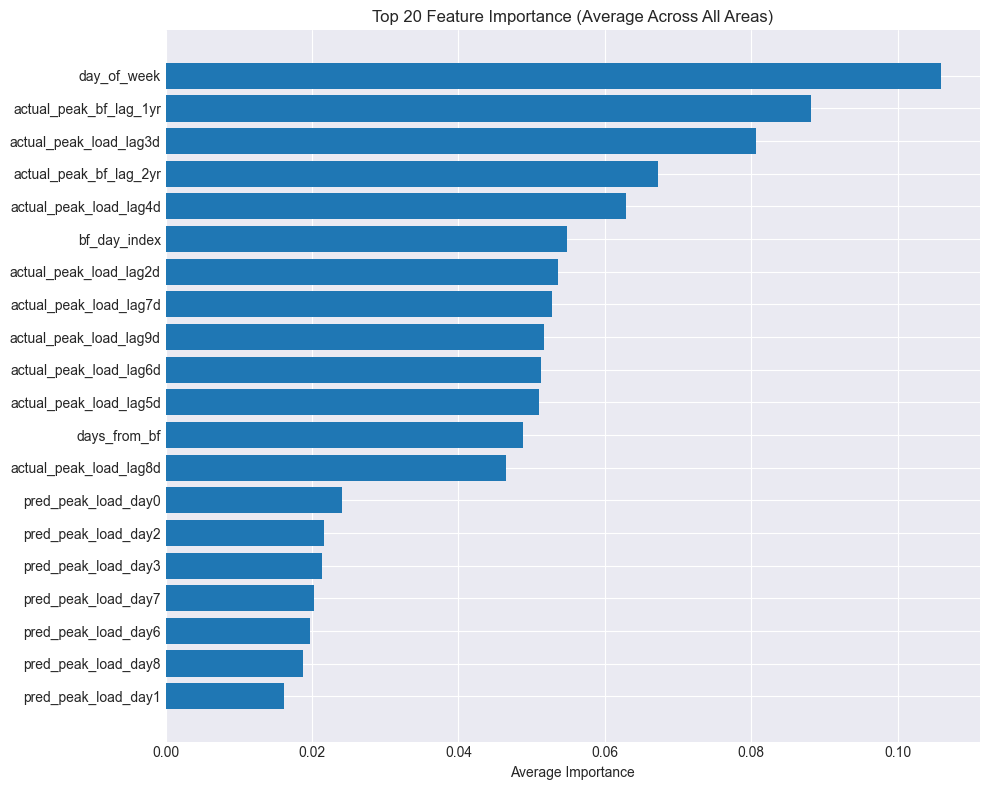


✓ Feature importance saved to: ../models/xgb_peak_day_feature_importance.csv
✓ Average importance saved to: ../models/xgb_peak_day_feature_importance_avg.csv


In [19]:
# Get feature importance for all areas
fi_rows = []

for area, model in area_models.items():
    importances = model.feature_importances_
    
    for feat, imp in zip(TIER1_FEATURES, importances):
        fi_rows.append({
            'load_area': area,
            'feature': feat,
            'importance': float(imp)
        })

feature_importance_df = pd.DataFrame(fi_rows)

# Normalize importance within each area
feature_importance_df['importance_norm'] = (
    feature_importance_df.groupby('load_area')['importance']
    .transform(lambda x: x / x.sum() if x.sum() > 0 else x)
)

# Average importance across all areas
avg_importance = feature_importance_df.groupby('feature')['importance_norm'].mean().reset_index()
avg_importance.columns = ['feature', 'avg_importance']
avg_importance = avg_importance.sort_values('avg_importance', ascending=False)

print("="*80)
print("AVERAGE FEATURE IMPORTANCE ACROSS ALL AREAS")
print("="*80)
print(avg_importance.to_string(index=False))

# Plot average importance
plt.figure(figsize=(10, 8))
plt.barh(avg_importance['feature'][:20], avg_importance['avg_importance'][:20])
plt.xlabel('Average Importance')
plt.title('Top 20 Feature Importance (Average Across All Areas)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save
fi_path = models_dir / 'xgb_peak_day_feature_importance.csv'
feature_importance_df.to_csv(fi_path, index=False)

avg_fi_path = models_dir / 'xgb_peak_day_feature_importance_avg.csv'
avg_importance.to_csv(avg_fi_path, index=False)

print(f"\n✓ Feature importance saved to: {fi_path}")
print(f"✓ Average importance saved to: {avg_fi_path}")

## Step 13: Evaluation with Area-Specific Models

In [20]:
print("="*80)
print("EVALUATION WITH AREA-SPECIFIC MODELS")
print("="*80)

# Predict using area-specific models
all_y_true = []
all_y_pred_proba = []
all_groups = []

for area in area_models.keys():
    # Get area data
    area_data = train_df[train_df['load_area'] == area].copy()
    
    if len(area_data) == 0:
        continue
    
    X_area = area_data[TIER1_FEATURES]
    y_area = area_data[TARGET]
    
    # Get model for this area
    model = area_models[area]
    
    # Predict
    y_pred_proba = model.predict_proba(X_area)[:, 1]
    
    # Store results
    all_y_true.extend(y_area.values)
    all_y_pred_proba.extend(y_pred_proba)
    all_groups.extend(zip(area_data['load_area'], area_data['year']))

# Evaluate overall performance
total_loss, total_fn, total_fp, metrics = evaluate_top2_loss(
    np.array(all_y_true), np.array(all_y_pred_proba), all_groups
)

print(f"\nTotal Loss: {total_loss:.1f}")
print(f"  False Negatives: {total_fn} (cost: {COST_FN} each)")
print(f"  False Positives: {total_fp} (cost: {COST_FP} each)")
print(f"\nMetrics:")
print(f"  FN Rate: {metrics['fn_rate']:.2%}")
print(f"  FP Rate: {metrics['fp_rate']:.2%}")

# Per-year breakdown
print(f"\n{'='*80}")
print("PER-YEAR BREAKDOWN")
print(f"{'='*80}")

for year in sorted(train_df['year'].unique()):
    year_y_true = []
    year_y_pred_proba = []
    year_groups = []
    
    for area in area_models.keys():
        area_year_data = train_df[(train_df['load_area'] == area) & (train_df['year'] == year)].copy()
        
        if len(area_year_data) == 0:
            continue
        
        X_area_year = area_year_data[TIER1_FEATURES]
        y_area_year = area_year_data[TARGET]
        
        model = area_models[area]
        y_pred_proba = model.predict_proba(X_area_year)[:, 1]
        
        year_y_true.extend(y_area_year.values)
        year_y_pred_proba.extend(y_pred_proba)
        year_groups.extend(zip(area_year_data['load_area'], area_year_data['year']))
    
    if len(year_y_true) > 0:
        loss, fn, fp, year_metrics = evaluate_top2_loss(
            np.array(year_y_true), np.array(year_y_pred_proba), year_groups
        )
        print(f"Year {year}: Loss={loss:.1f} (FN={fn}, FP={fp})")

# Per-area breakdown
print(f"\n{'='*80}")
print("PER-AREA BREAKDOWN")
print(f"{'='*80}")

area_results = []
for area in sorted(area_models.keys()):
    area_data = train_df[train_df['load_area'] == area].copy()
    
    if len(area_data) == 0:
        continue
    
    X_area = area_data[TIER1_FEATURES]
    y_area = area_data[TARGET]
    
    model = area_models[area]
    y_pred_proba = model.predict_proba(X_area)[:, 1]
    
    area_groups = list(zip(area_data['load_area'], area_data['year']))
    
    loss, fn, fp, area_metrics = evaluate_top2_loss(
        y_area.values, y_pred_proba, area_groups
    )
    
    area_results.append({
        'area': area,
        'loss': loss,
        'fn': fn,
        'fp': fp
    })

area_results_df = pd.DataFrame(area_results).sort_values('loss', ascending=False)
print(f"\nTop 10 worst performing areas:")
print(area_results_df.head(10).to_string(index=False))
print(f"\nTop 10 best performing areas:")
print(area_results_df.tail(10).to_string(index=False))

EVALUATION WITH AREA-SPECIFIC MODELS

Total Loss: 325.0
  False Negatives: 65 (cost: 4 each)
  False Positives: 65 (cost: 1 each)

Metrics:
  FN Rate: 12.70%
  FP Rate: 3.17%

PER-YEAR BREAKDOWN
Year 2016: Loss=5.0 (FN=1, FP=1)
Year 2017: Loss=20.0 (FN=4, FP=4)
Year 2018: Loss=75.0 (FN=15, FP=15)
Year 2019: Loss=35.0 (FN=7, FP=7)
Year 2020: Loss=50.0 (FN=10, FP=10)
Year 2021: Loss=40.0 (FN=8, FP=8)
Year 2022: Loss=20.0 (FN=4, FP=4)
Year 2023: Loss=15.0 (FN=3, FP=3)
Year 2024: Loss=65.0 (FN=13, FP=13)

PER-AREA BREAKDOWN

Top 10 worst performing areas:
  area  loss  fn  fp
AEPAPT    40   8   8
 PAPWR    30   6   6
 DPLCO    25   5   5
  AECO    20   4   4
    PN    20   4   4
AEPKPT    20   4   4
  RECO    15   3   3
EASTON    15   3   3
AEPIMP    15   3   3
    JC    15   3   3

Top 10 best performing areas:
  area  loss  fn  fp
  VMEU     5   1   1
   DUQ     5   1   1
    CE     5   1   1
  OVEC     0   0   0
  PLCO     0   0   0
  DEOK     0   0   0
    BC     0   0   0
 SMECO     0

## Summary

In [21]:
print("="*80)
print("PEAK DAY CLASSIFICATION SUMMARY (AREA-SPECIFIC MODELS)")
print("="*80)
print(f"\nTask: Binary classification for peak day prediction")
print(f"Period: BF{BF_START_OFFSET} to BF+{BF_END_OFFSET} ({BF_PERIOD_DAYS} days)")
print(f"Target: Top {TOP_N_PEAK_DAYS} peak days per (area, year)")
print(f"\nLoss function: {COST_FN}×FN + {COST_FP}×FP")
print(f"\nModel Type: Area-Specific XGBoost Binary Classifiers")
print(f"Number of models: {len(area_models)}")
print(f"\nFeatures: {len(TIER1_FEATURES)} (Tier 1)")
print(f"  - Predicted load (4-yr avg): {BF_PERIOD_DAYS}")
print(f"  - Day index: 1")
print(f"  - Temporal: 4")
print(f"  - Actual lags: 5")
print(f"  - Historical BF: 2")
print(f"\nHyperparameters:")
print(f"  Area-specific optimization (best params per area)")
print(f"  Average CV loss across areas: {best_params_df['avg_loss'].mean():.2f}")
print(f"\nFinal Model Performance (all years):")
print(f"  Total Loss: {total_loss:.1f}")
print(f"  FN: {total_fn}, FP: {total_fp}")
print(f"  FN Rate: {metrics['fn_rate']:.2%}")
print(f"  FP Rate: {metrics['fp_rate']:.2%}")
print(f"\nComparison to random baseline:")
random_loss = len(train_df['load_area'].unique()) * len(train_df['year'].unique()) * (COST_FN * 1.6 + COST_FP * 1.6)
improvement = (1 - total_loss/random_loss) * 100
print(f"  Random expected loss: ~{random_loss:.0f}")
print(f"  Improvement: {improvement:.1f}%")
print("="*80)

PEAK DAY CLASSIFICATION SUMMARY (AREA-SPECIFIC MODELS)

Task: Binary classification for peak day prediction
Period: BF-8 to BF+1 (10 days)
Target: Top 2 peak days per (area, year)

Loss function: 4×FN + 1×FP

Model Type: Area-Specific XGBoost Binary Classifiers
Number of models: 29

Features: 26 (Tier 1)
  - Predicted load (4-yr avg): 10
  - Day index: 1
  - Temporal: 4
  - Actual lags: 5
  - Historical BF: 2

Hyperparameters:
  Area-specific optimization (best params per area)
  Average CV loss across areas: 5.24

Final Model Performance (all years):
  Total Loss: 325.0
  FN: 65, FP: 65
  FN Rate: 12.70%
  FP Rate: 3.17%

Comparison to random baseline:
  Random expected loss: ~2088
  Improvement: 84.4%
